In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("/home/zz1994/packages/ABCMB")
import jax
print(jax.devices())

ERROR:2025-12-12 18:25:31,541:jax._src.xla_bridge:487: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/ext3/miniforge3/lib/python3.12/site-packages/jax/_src/xla_bridge.py", line 485, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/ext3/miniforge3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/ext3/miniforge3/lib/python3.12/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


[CpuDevice(id=0)]


In [3]:
from classy import Class
import jax.numpy as jnp
import numpy as np
from jax import jit, vmap, lax, grad, config, jacfwd
import equinox as eqx
import matplotlib.pyplot as plt
import time

from ABCMB import main, background, perturbations, spectrum, model_specs, species
from ABCMB import constants as cnst
from ABCMB import ABCMBTools as tools
from ABCMB.hyrex import hyrex

In [6]:
from pytests import accuracy_test

accuracy_test.test_accuracy_checker()

# Plots for the Paper

## Computing and Saving

In [6]:
specs = {
    "output_Cl" : True,
    "lensing" : True,
    "output_Pk" : True,
    "output_k_max" : 0.4,
}

lcdm_unlensed = main.Model(specs, user_species=None)
mnu_unlensed = main.Model(specs, user_species=(species.MassiveNeutrino,)) 

specs["lensing"] = True
mnu_lensed = main.Model(specs, user_species=(species.MassiveNeutrino,)) 

In [15]:
params_lcdm = {
    'h': 0.6762,
    'omega_cdm': 0.1293,
    'omega_b': 0.0225,
    'A_s': 2.12424e-9,
    'n_s': 0.9709,
    'Neff': 3.044,
    'YHe': 0.245,
    'N_nu_massive': 0,
    'T_nu_massive': 0.71611,
    'm_nu_massive': 0.06,
    "z_reion": 11.,
    "Delta_z_reion": 0.5,
    "z_reion_He": 3.5,
    "Delta_z_reion_He": 0.5,
}

params_mnu = {
    'h': 0.6762,
    'omega_cdm': 0.1293,
    'omega_b': 0.0225,
    'A_s': 2.12424e-9,
    'n_s': 0.9709,
    'Neff': 3.044,
    'YHe': 0.245,
    'N_nu_massive': 1,
    'T_nu_massive': 0.71611,
    'm_nu_massive': 0.06,
    "z_reion": 11.,
    "Delta_z_reion": 0.5,
    "z_reion_He": 3.5,
    "Delta_z_reion_He": 0.5,
}

In [8]:
output_lcdm_unlensed, aux_lcdm_unlensed = lcdm_unlensed.run_cosmology(params_lcdm)
output_mnu_unlensed, aux_mnu_unlensed = mnu_unlensed.run_cosmology(params_mnu)
output_mnu_lensed, aux_mnu_lensed = mnu_lensed.run_cosmology(params_mnu)


              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      


              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      


              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      



In [12]:
np.savetxt("Plots/lcdm_unlensed_tt.txt", output_lcdm_unlensed[0])
np.savetxt("Plots/lcdm_unlensed_ee.txt", output_lcdm_unlensed[2])
np.savetxt("Plots/lcdm_unlensed_Pk.txt", output_lcdm_unlensed[3])
np.savetxt("Plots/lcdm_unlensed_kk.txt", aux_lcdm_unlensed[0])

np.savetxt("Plots/mnu_unlensed_tt.txt", output_mnu_unlensed[0])
np.savetxt("Plots/mnu_unlensed_ee.txt", output_mnu_unlensed[2])

np.savetxt("Plots/mnu_lensed_tt.txt", output_mnu_lensed[0])
np.savetxt("Plots/mnu_lensed_ee.txt", output_mnu_lensed[2])

## Plotting Specs

In [12]:
import numpy as np
import jax.numpy as jnp
from cycler import cycler
import palettable
import seaborn as sns

params = {'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
        #   'animation.avconv_args': [],
        #   'animation.avconv_path': 'avconv',
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': [],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
        #   'animation.html_args': [],
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-7, 7],
          'axes.formatter.min_exponent': 2,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'both',
          'axes.grid.which': 'major',
          'axes.labelcolor': 'black',
          'axes.labelpad': 10.0,
          'axes.labelsize': 19.0,
          'axes.labelweight': 'normal',
          'axes.linewidth': 1.8,
          'axes.prop_cycle': cycler('color', sns.color_palette("Set1", 10, desat=0.7).as_hex()) + 
                            cycler(alpha=10*[.9]), 
          # 'axes.prop_cycle': cycler('color', sns.color_palette('husl', 10).as_hex()),
          'axes.spines.bottom': True,
          'axes.spines.left': True,
          'axes.spines.right': True,
          'axes.spines.top': True,
          'axes.titlepad': 7.5,
          'axes.titlesize': 18.0,
          'axes.titleweight': 'normal',
          'axes.unicode_minus': True,
          'axes.xmargin': 0.05,
          'axes.ymargin': 0.05,
          'axes3d.grid': True,
          'backend': 'module://ipykernel.pylab.backend_inline',
          'backend_fallback': True,
          'boxplot.bootstrap': None,
          'boxplot.boxprops.color': 'black',
          'boxplot.boxprops.linestyle': '-',
          'boxplot.boxprops.linewidth': 1.0,
          'boxplot.capprops.color': 'black',
          'boxplot.capprops.linestyle': '-',
          'boxplot.capprops.linewidth': 1.0,
          'boxplot.flierprops.color': 'black',
          'boxplot.flierprops.linestyle': 'none',
          'boxplot.flierprops.linewidth': 1.0,
          'boxplot.flierprops.marker': 'o',
          'boxplot.flierprops.markeredgecolor': 'black',
          'boxplot.flierprops.markerfacecolor': 'none',
          'boxplot.flierprops.markersize': 6.0,
          'boxplot.meanline': False,
          'boxplot.meanprops.color': 'C2',
          'boxplot.meanprops.linestyle': '--',
          'boxplot.meanprops.linewidth': 1.0,
          'boxplot.meanprops.marker': '^',
          'boxplot.meanprops.markeredgecolor': 'C2',
          'boxplot.meanprops.markerfacecolor': 'C2',
          'boxplot.meanprops.markersize': 6.0,
          'boxplot.medianprops.color': 'C1',
          'boxplot.medianprops.linestyle': '-',
          'boxplot.medianprops.linewidth': 1.0,
          'boxplot.notch': False,
          'boxplot.patchartist': False,
          'boxplot.showbox': True,
          'boxplot.showcaps': True,
          'boxplot.showfliers': True,
          'boxplot.showmeans': False,
          'boxplot.vertical': True,
          'boxplot.whiskerprops.color': 'black',
          'boxplot.whiskerprops.linestyle': '-',
          'boxplot.whiskerprops.linewidth': 1.0,
          'boxplot.whiskers': 1.5,
          'contour.corner_mask': True,
          'contour.negative_linestyle': 'dashed',
          # 'datapath': '/Users/smsharma/anaconda3/lib/python3.7/site-packages/matplotlib/mpl-data',
          'date.autoformatter.day': '%Y-%m-%d',
          'date.autoformatter.hour': '%m-%d %H',
          'date.autoformatter.microsecond': '%M:%S.%f',
          'date.autoformatter.minute': '%d %H:%M',
          'date.autoformatter.month': '%Y-%m',
          'date.autoformatter.second': '%H:%M:%S',
          'date.autoformatter.year': '%Y',
          'docstring.hardcopy': False,
          'errorbar.capsize': 0.0,
          'figure.autolayout': False,
          'figure.constrained_layout.h_pad': 0.04167,
          'figure.constrained_layout.hspace': 0.02,
          'figure.constrained_layout.use': False,
          'figure.constrained_layout.w_pad': 0.04167,
          'figure.constrained_layout.wspace': 0.02,
          'figure.dpi': 72.0,
          'figure.edgecolor': (1, 1, 1, 0),
          'figure.facecolor': (1, 1, 1, 0),
          'figure.figsize': [6.153846153846153, 5.0],
          'figure.frameon': True,
          'figure.max_open_warning': 20,
          'figure.subplot.bottom': 0.125,
          'figure.subplot.hspace': 0.2,
          'figure.subplot.left': 0.125,
          'figure.subplot.right': 0.9,
          'figure.subplot.top': 0.88,
          'figure.subplot.wspace': 0.2,
          'figure.titlesize': 'large',
          'figure.titleweight': 'normal',
          'font.cursive': ['Apple Chancery',
                           'Textile',
                           'Zapf Chancery',
                           'Sand',
                           'Script MT',
                           'Felipa',
                           'cursive'],
          'font.family': ['serif'],
          'font.fantasy': ['Comic Sans MS',
                           'Chicago',
                           'Charcoal',
                           'Impact',
                           'Western',
                           'Humor Sans',
                           'xkcd',
                           'fantasy'],
          'font.monospace': ['DejaVu Sans Mono',
                             'Bitstream Vera Sans Mono',
                             'Computer Modern Typewriter',
                             'Andale Mono',
                             'Nimbus Mono L',
                             'Courier New',
                             'Courier',
                             'Fixed',
                             'Terminal',
                             'monospace'],
          'font.sans-serif': ['CMU Sans Serif'],
          'font.serif': ['CMU Serif'],
          'font.size': 10.0,
          'font.stretch': 'normal',
          'font.style': 'normal',
          'font.variant': 'normal',
          'font.weight': 'normal',
          'grid.alpha': 1.0,
          'grid.color': '#b0b0b0',
          'grid.linestyle': '-',
          'grid.linewidth': 0.8,
          'hatch.color': 'black',
          'hatch.linewidth': 1.0,
          'hist.bins': 10,
          'image.aspect': 'equal',
          'image.cmap': 'viridis',
          'image.composite_image': True,
          'image.interpolation': 'nearest',
          'image.lut': 256,
          'image.origin': 'upper',
          'image.resample': True,
          'interactive': True,
        #   'keymap.all_axes': ['a'],
          'keymap.back': ['left', 'c', 'backspace'],
          'keymap.copy': ['ctrl+c', 'cmd+c'],
          'keymap.forward': ['right', 'v'],
          'keymap.fullscreen': ['f', 'ctrl+f'],
          'keymap.grid': ['g'],
          'keymap.grid_minor': ['G'],
          'keymap.help': ['f1'],
          'keymap.home': ['h', 'r', 'home'],
          'keymap.pan': ['p'],
          'keymap.quit': ['ctrl+w', 'cmd+w', 'q'],
          'keymap.quit_all': ['W', 'cmd+W', 'Q'],
          'keymap.save': ['s', 'ctrl+s'],
          'keymap.xscale': ['k', 'L'],
          'keymap.yscale': ['l'],
          'keymap.zoom': ['o'],
          'legend.borderaxespad': 0.5,
          'legend.borderpad': 0.4,
          'legend.columnspacing': 2.0,
          'legend.edgecolor': '0.8',
          'legend.facecolor': 'inherit',
          'legend.fancybox': True,
          'legend.fontsize': 17.0,
          'legend.framealpha': 0.4,
          'legend.frameon': False,
          'legend.handleheight': 0.7,
          'legend.handlelength': 2.0,
          'legend.handletextpad': 0.8,
          'legend.labelspacing': 0.5,
          'legend.loc': 'best',
          'legend.markerscale': 1.0,
          'legend.numpoints': 1,
          'legend.scatterpoints': 1,
          'legend.shadow': False,
          'legend.title_fontsize': None,
          'lines.antialiased': True,
          'lines.color': 'C0',
          'lines.dash_capstyle': 'butt',
          'lines.dash_joinstyle': 'round',
          'lines.dashdot_pattern': [6.4, 1.6, 1.0, 1.6],
          'lines.dashed_pattern': [3.7, 1.6],
          'lines.dotted_pattern': [1.0, 1.65],
          'lines.linestyle': '-',
          'lines.linewidth': 2.5,
          'lines.marker': 'None',
          'lines.markeredgecolor': 'auto',
          'lines.markeredgewidth': 1.0,
          'lines.markerfacecolor': 'auto',
          'lines.markersize': 6.0,
          'lines.scale_dashes': True,
          'lines.solid_capstyle': 'projecting',
          'lines.solid_joinstyle': 'round',
          'markers.fillstyle': 'full',
          'mathtext.bf': 'sans:bold',
          'mathtext.cal': 'cursive',
          'mathtext.default': 'it',
        #   'mathtext.fallback_to_cm': True,
          'mathtext.fontset': 'dejavusans',
          'mathtext.it': 'sans:italic',
          'mathtext.rm': 'sans',
          'mathtext.sf': 'sans',
          'mathtext.tt': 'monospace',
          'patch.antialiased': True,
          'patch.edgecolor': 'black',
          'patch.facecolor': 'C0',
          'patch.force_edgecolor': False,
          'patch.linewidth': 1.0,
          'path.effects': [],
          'path.simplify': True,
          'path.simplify_threshold': 0.1111111111111111,
          'path.sketch': None,
          'path.snap': True,
          'pdf.compression': 6,
          'pdf.fonttype': 3,
          'pdf.inheritcolor': False,
          'pdf.use14corefonts': False,
          # 'pgf.preamble': [],
          'pgf.rcfonts': True,
          'pgf.texsystem': 'xelatex',
          'polaraxes.grid': True,
          'ps.distiller.res': 6000,
          'ps.fonttype': 3,
          'ps.papersize': 'letter',
          'ps.useafm': False,
          'ps.usedistiller': False,
          'savefig.bbox': None,
          'savefig.directory': '~',
          'savefig.dpi': 'figure',
          'savefig.edgecolor': 'white',
          'savefig.facecolor': 'white',
          'savefig.format': 'png',
        #   'savefig.jpeg_quality': 95,
          'savefig.orientation': 'portrait',
          'savefig.pad_inches': 0.1,
          'savefig.transparent': False,
          'scatter.marker': 'o',
          'svg.fonttype': 'path',
          'svg.hashsalt': None,
          'svg.image_inline': True,
          'text.antialiased': True,
          'text.color': 'black',
          'text.hinting': 'auto',
          'text.hinting_factor': 8,
          # 'text.latex.preamble': [],
        #   'text.latex.preview': False,
          'text.usetex': True,
          'timezone': 'UTC',
          'tk.window_focus': False,
          'toolbar': 'toolbar2',
          'webagg.address': '127.0.0.1',
          'webagg.open_in_browser': True,
          'webagg.port': 8988,
          'webagg.port_retries': 50,
          'xtick.alignment': 'center',
          'xtick.bottom': True,
          'xtick.color': 'black',
          'xtick.direction': 'in',
          'xtick.labelbottom': True,
          'xtick.labelsize': 17.5,
          'xtick.labeltop': False,
          'xtick.major.bottom': True,
          'xtick.major.pad': 6.0,
          'xtick.major.size': 7.0,
          'xtick.major.top': True,
          'xtick.major.width': 1.0,
          'xtick.minor.bottom': True,
          'xtick.minor.pad': 3.4,
          'xtick.minor.size': 3.0,
          'xtick.minor.top': True,
          'xtick.minor.visible': True,
          'xtick.minor.width': 0.8,
          'xtick.top': True,
          'ytick.alignment': 'center_baseline',
          'ytick.color': 'black',
          'ytick.direction': 'in',
          'ytick.labelleft': True,
          'ytick.labelright': False,
          'ytick.labelsize': 17.5,
          'ytick.left': True,
          'ytick.major.left': True,
          'ytick.major.pad': 6.0,
          'ytick.major.right': True,
          'ytick.major.size': 7.0,
          'ytick.major.width': 1.0,
          'ytick.minor.left': True,
          'ytick.minor.pad': 3.4,
          'ytick.minor.right': True,
          'ytick.minor.size': 3.0,
          'ytick.minor.visible': True,
          'ytick.minor.width': 0.8,
          'ytick.right': True}
import matplotlib
for key, value in params.items():
    matplotlib.rcParams[key] = value
import matplotlib.pyplot as plt

## Plots

In [14]:
l = jnp.arange(2, 2501)


# Setup

In [5]:
params = {
    'h': 0.6762,
    'omega_cdm': 0.1293,
    'omega_b': 0.0225,
    'A_s': 2.12424e-9,
    'n_s': 0.9709,
    'Neff': 3.044,
    'YHe': 0.245,
    'TCMB0': 2.34865418e-4,
    #'T_nu_massless' : 0.71636,
    #'N_nu_massless' : 3,
    'N_nu_massive': 1,
    'T_nu_massive': 0.71611,
    'm_nu_massive': 0.06,
    "z_reion": 11.,
    "Delta_z_reion": 0.5,
    "z_reion_He": 3.5,
    "Delta_z_reion_He": 0.5,
}

lmax = 2500
specs = {
    "output_Cl" : True,
    "l_max" : lmax,
    "lensing" : True,
    "output_Pk" : True,
    "output_k_max" : 0.4,
    "l_max_g" : 12,
    "l_max_pol_g" : 10,
    "l_max_ur" : 17,
    "l_max_ncdm" : 17,
    "output_background" : True,
    "output_perturbations" : True,
}
if params["N_nu_massive"] > 0:
    user_species = (
        species.MassiveNeutrino,
    )
else:
    user_species = None

#model = main.Model(user_species=user_species, input_specs=specs, return_PTBG=True, bbn_type="linX")
model = main.Model(user_species=user_species, input_specs=specs)
#params = eqx.filter_jit(model.add_derived_parameters)(params)
#params = model.add_derived_parameters(params)
#params

In [6]:
for i in range(1):
    s = time.time()
    data, label = model.run_cosmology(params)
    print(time.time() - s)


              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      

374.2961091995239


In [13]:
for i in range(1):
    s = time.time()
    class_params = {
        "output": "mPk, tCl, pCl, lCl" if specs["lensing"] else "mPk, tCl, pCl",
        "P_k_max_1/Mpc" : specs["output_k_max"],
        "l_max_scalars" : lmax,
        "k_output_values" : "0.001, 0.01, 0.1, 0.4",
        "lensing" : "yes" if specs["lensing"] else "no",
        "H0": params["h"]*100,
        "omega_b": params["omega_b"],
        "omega_cdm": params["omega_cdm"],
        "A_s" : params["A_s"],
        "n_s" : params["n_s"],
        "N_ur": 2.0308,
        "YHe": params["YHe"],
        "N_ncdm": params["N_nu_massive"],
        #"reio_parametrization" : "reio_none",
        "reio_parametrization" : "reio_camb",
        "z_reio" : params["z_reion"],
        "reionization_width" : params["Delta_z_reion"],
        "helium_fullreio_redshift" : params["z_reion_He"],
        "helium_fullreio_width" : params["Delta_z_reion_He"],
        "reionization_exponent" : 1.5,
        "l_max_g": specs["l_max_g"],
        "l_max_pol_g": specs["l_max_pol_g"],
        "l_max_ur": specs["l_max_ur"], 
        "l_max_ncdm":specs["l_max_ncdm"]}
        #"radiation_streaming_trigger_tau_over_tau_k" : 20000,
        #"radiation_streaming_trigger_tau_c_over_tau" : 2000,
        #"ur_fluid_trigger_tau_over_tau_k" : 10000, 
        #"ncdm_fluid_trigger_tau_over_tau_k" : 15000} 
    class_lcdm = Class()
    class_lcdm.set(class_params)
    if params["N_nu_massive"] > 0:
        class_lcdm.set({"m_ncdm": params["m_nu_massive"], "T_ncdm": params["T_nu_massive"]})
    class_lcdm.compute()
    print(time.time() - s)

9.044212579727173


# Background Check

## Hubble

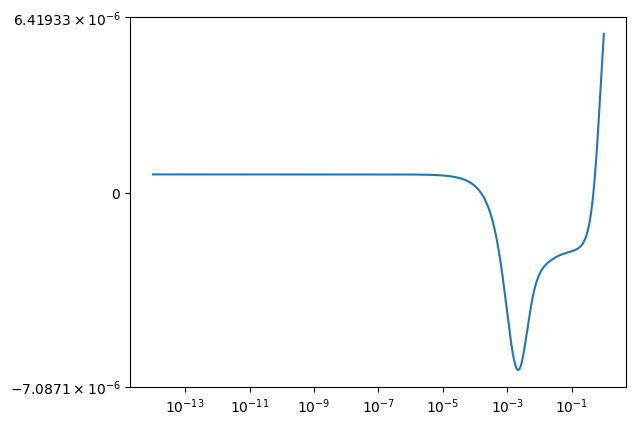

In [14]:
class_bg = class_lcdm.get_background()
BG = label[4]
a = 1/(1.+class_bg["z"])
H_class = class_bg['H [1/Mpc]'] * cnst.c_Mpc_over_s
H_ABCMB = BG.H(jnp.log(a), params)
plt.plot(a, (H_class - H_ABCMB)/H_class)
plt.yscale("symlog")
plt.xscale("log")
plt.show()

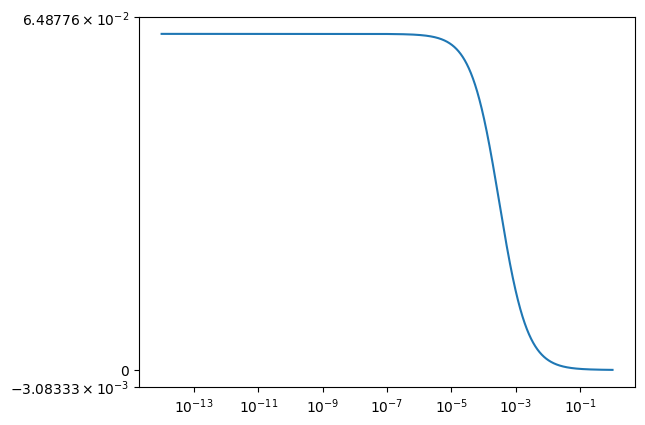

In [12]:
class_bg = class_lcdm.get_background()
BG = label[4]
params = label[2]
a = 1/(1.+class_bg["z"])
H_class = class_bg['H [1/Mpc]'] * cnst.c_Mpc_over_s
H_ABCMB = BG.H(jnp.log(a), params)
plt.plot(a, (H_class - H_ABCMB)/H_class)
plt.yscale("symlog")
plt.xscale("log")
plt.show()

## Massive Neutrino Density

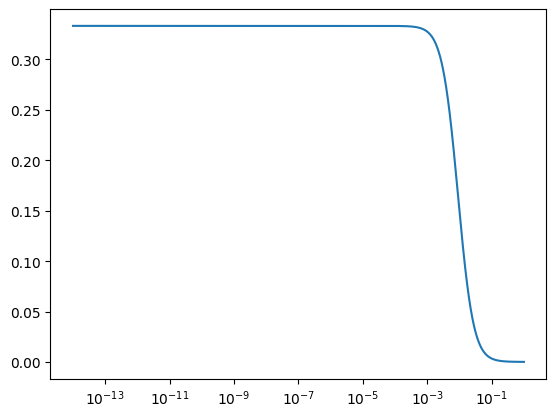

In [15]:
rho_nu_class = class_bg[ '(.)p_ncdm[0]']/class_bg[ '(.)rho_ncdm[0]']
plt.plot(a, rho_nu_class)
#rho_nu_ABCMB = BG.H(jnp.log(a), params)
#plt.plot(a, (H_class - H_ABCMB)/H_class)
#plt.yscale("symlog")
#plt.xscale("log")
#plt.xlim((1.e-5, 1.))
plt.xscale("log")
plt.show()

# Thermodynamics Check

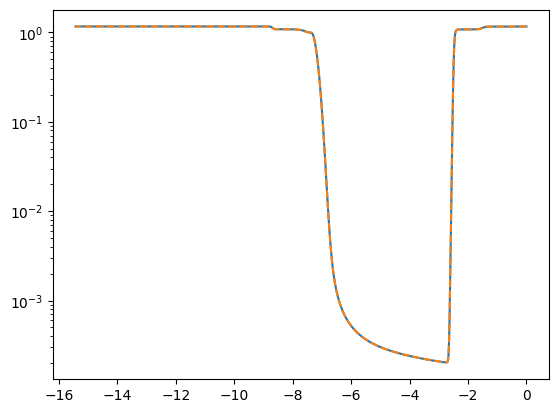

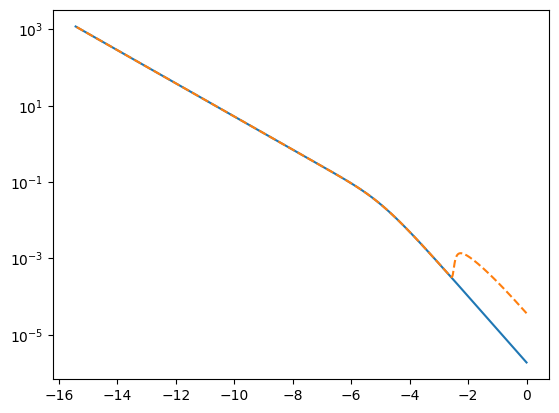

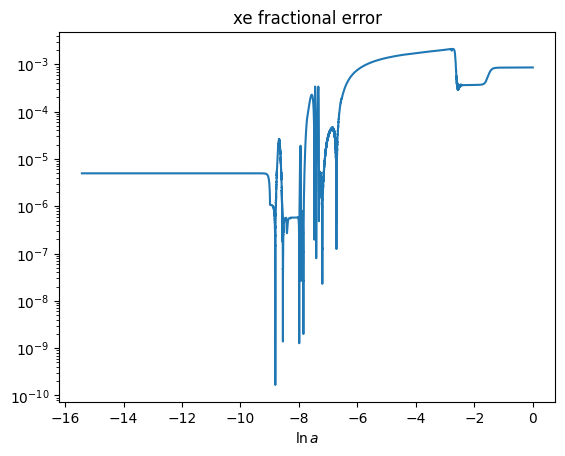

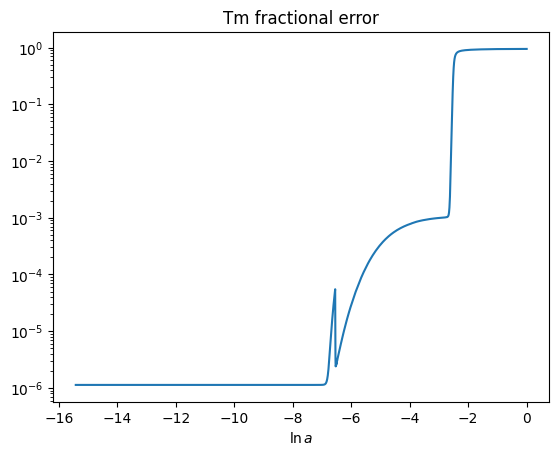

In [8]:
class_rec = class_lcdm.get_thermodynamics()
a = 1/(1.+class_rec["z"])
xe_class = class_rec["x_e"]
Tm_class = class_rec['Tb [K]'] * cnst.kB
xe_abcmb = BG.xe(jnp.log(a))
Tm_abcmb = BG.Tm(jnp.log(a))

plt.plot(jnp.log(a), xe_abcmb)
plt.plot(jnp.log(a), xe_class, "--")
plt.yscale("log")
plt.show()

plt.plot(jnp.log(a), Tm_abcmb)
plt.plot(jnp.log(a), Tm_class, "--")
plt.yscale("log")
plt.show()

plt.plot(jnp.log(a), abs(xe_abcmb-xe_class)/xe_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
plt.title("xe fractional error")
#plt.xlim((-8, -6))
plt.show()

plt.plot(jnp.log(a), abs(Tm_abcmb-Tm_class)/Tm_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
#plt.xlim((-8, -6))
plt.title("Tm fractional error")
plt.show()

In [18]:
expmkappa_class = class_rec["exp(-kappa)"]
g_class = class_rec["g [Mpc^-1]"]
expmkappa_abcmb = vmap(BG.expmkappa)(jnp.log(a))
g_abcmb = vmap(BG.visibility)(jnp.log(a))

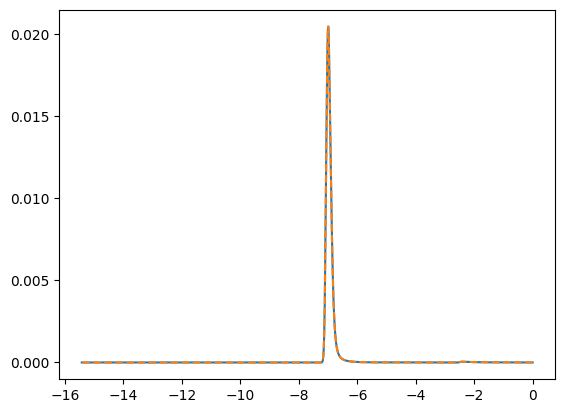

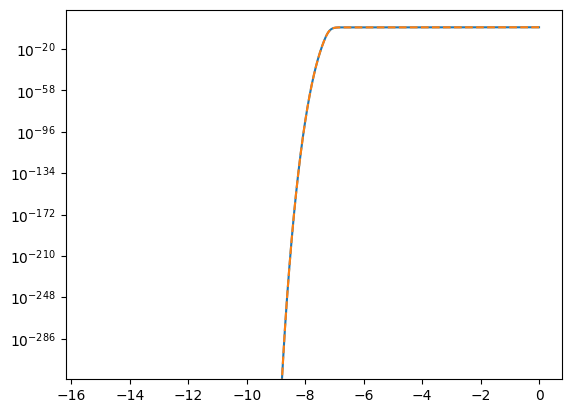

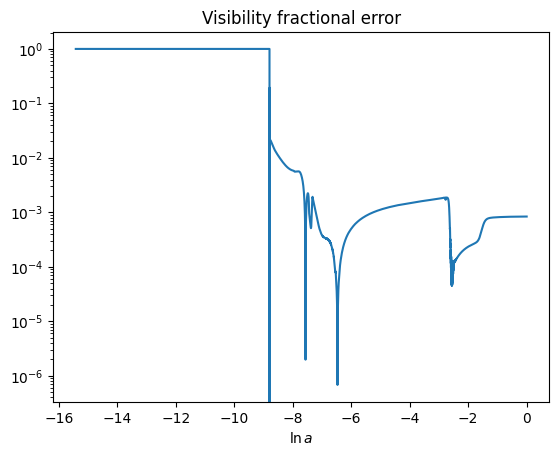

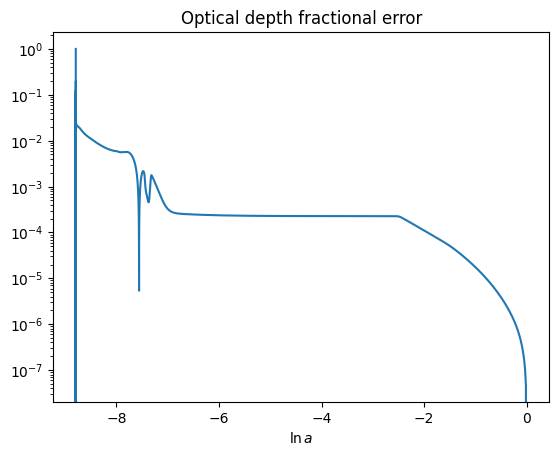

In [19]:
plt.plot(jnp.log(a), g_abcmb)
plt.plot(jnp.log(a), g_class, "--")
plt.show()

plt.plot(jnp.log(a), expmkappa_abcmb)
plt.plot(jnp.log(a), expmkappa_class, "--")
plt.yscale("log")
plt.show()

plt.plot(jnp.log(a), abs(g_abcmb-g_class)/g_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
plt.title("Visibility fractional error")
#plt.xlim((-8, -6))
plt.show()

plt.plot(jnp.log(a), abs(expmkappa_abcmb-expmkappa_class)/expmkappa_class)
plt.yscale("log")
plt.xlabel(r"$\ln{a}$")
#plt.xlim((-8, -6))
plt.title("Optical depth fractional error")
plt.show()

# Cl's

In [16]:
if specs["lensing"]:
    class_ell = class_lcdm.lensed_cl(lmax)["ell"]
    class_tt = class_lcdm.lensed_cl(lmax)["tt"] * class_ell * (class_ell+1)/2./jnp.pi
    class_te = class_lcdm.lensed_cl(lmax)["te"] * class_ell * (class_ell+1)/2./jnp.pi
    class_ee = class_lcdm.lensed_cl(lmax)["ee"] * class_ell * (class_ell+1)/2./jnp.pi

else:
    class_ell = class_lcdm.raw_cl(lmax)["ell"]
    class_tt = class_lcdm.raw_cl(lmax)["tt"] * class_ell * (class_ell+1)/2./jnp.pi
    class_te = class_lcdm.raw_cl(lmax)["te"] * class_ell * (class_ell+1)/2./jnp.pi
    class_ee = class_lcdm.raw_cl(lmax)["ee"] * class_ell * (class_ell+1)/2./jnp.pi

ells = label[0]
abcmb_tt = ells*(ells+1)/2./jnp.pi * data[0]
abcmb_te = ells*(ells+1)/2./jnp.pi * data[1]
abcmb_ee = ells*(ells+1)/2./jnp.pi * data[2]

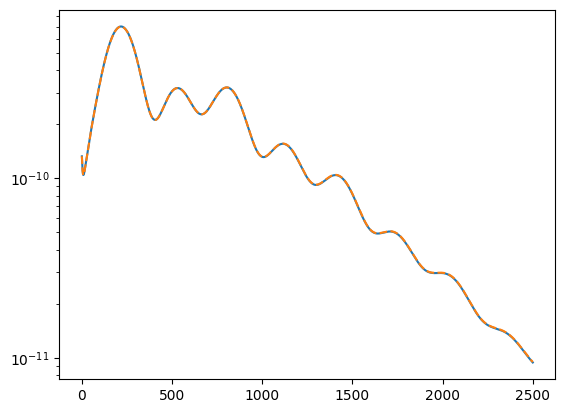

In [17]:
full_l = model.SS.ells
l = full_l[:]
plt.plot(l, abcmb_tt)
plt.plot(l, class_tt[l], "--")
plt.yscale("log")
plt.show()

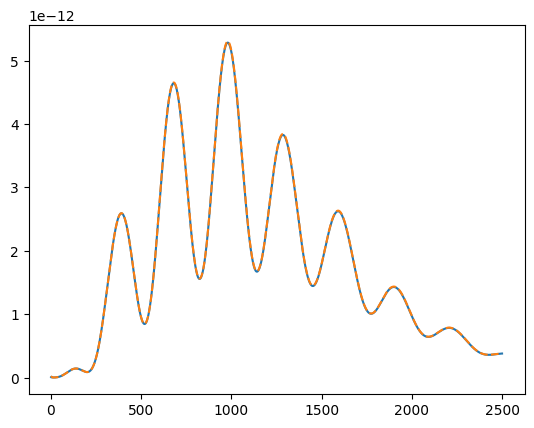

In [18]:
full_l = model.SS.ells
l = full_l[:]
plt.plot(l, abcmb_ee[l-2])
plt.plot(l, class_ee[l], "--")
plt.show()

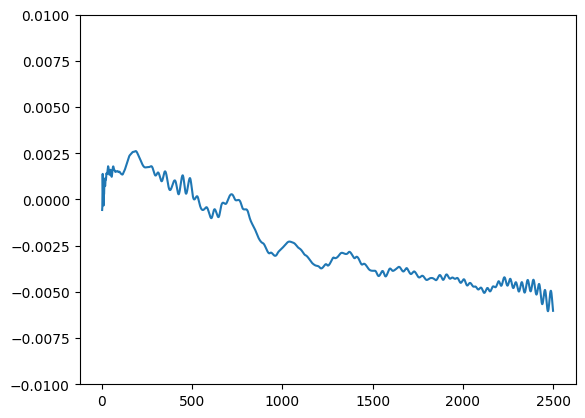

In [19]:
err = abcmb_tt[l-2]/class_tt[l] - 1.
plt.plot(l, err)
plt.ylim((-0.01, 0.01))
#plt.xlim((2, 2500))
plt.show()

In [7]:
params = label[2]
PT = label[3]
BG = label[4]

In [20]:
l=2
idx=0
tau0 = BG.tau0
tau = BG.tau(PT.lna)
k_T0_axis = model.SS.k_axis_transfer
chiT0 = jnp.outer(tau0-tau, k_T0_axis)
phi0_tab = spectrum.phi0(idx, chiT0)

In [31]:
epsilon_tab = phi0_tab / chiT0**2

In [34]:
epsilon_tab = epsilon_tab.at[-1].set(
    jnp.where(
        l == 2,
        jnp.ones(k_T0_axis.size)/15.,
        jnp.zeros(k_T0_axis.size)
    )
)

In [35]:
epsilon_tab

Array([[ 6.95703757e-02,  6.84866359e-02,  7.18626355e-02, ...,
        -1.25037932e-11,  1.11772797e-11, -8.09341169e-12],
       [ 6.95832270e-02,  6.84762257e-02,  7.18560135e-02, ...,
        -8.21588566e-12,  3.84132061e-12,  1.12378110e-12],
       [ 6.95962044e-02,  6.84657046e-02,  7.18493191e-02, ...,
         1.09778568e-12, -5.89341371e-12,  9.73422685e-12],
       ...,
       [ 8.18647980e+00,  7.60394504e+00,  7.06296461e+00, ...,
         1.74940116e-05,  1.72118948e-05,  1.69108814e-05],
       [ 1.88334084e+01,  1.74932579e+01,  1.62487052e+01, ...,
         9.39102934e-05,  9.59865043e-05,  9.80573745e-05],
       [ 6.66666667e-02,  6.66666667e-02,  6.66666667e-02, ...,
         6.66666667e-02,  6.66666667e-02,  6.66666667e-02]],      dtype=float64)

In [77]:
_, _, my_ee = 

Array(6.3727684e-15, dtype=float64)

In [41]:
_, _, my_ee = model.SS.get_Cl(PT, BG, params)

In [48]:
my_ee *= l*(l+1)/2/jnp.pi

In [20]:
err = my_ee[l-2]/class_ee[l] - 1.
plt.plot(l, err)
#plt.ylim((-0.01, 0.01))
#plt.xlim((2, 2500))
plt.show()

NameError: name 'my_ee' is not defined

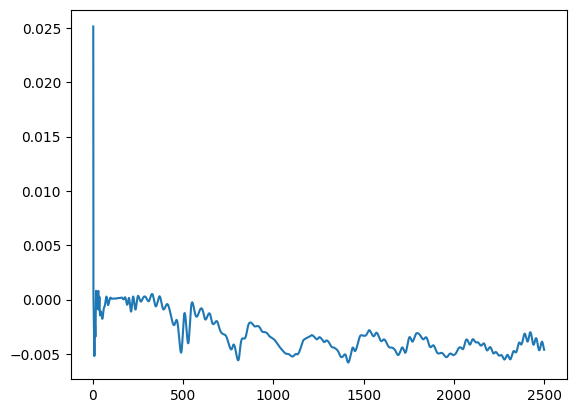

In [21]:
err = abcmb_ee[l-2]/class_ee[l] - 1.
plt.plot(l, err)
#plt.ylim((-0.01, 0.01))
#plt.xlim((2, 2500))
plt.show()

## P(k)

In [242]:
class_dat = np.loadtxt("/home/zz1994/packages/class/output/ABCMB_test/neutrinos_pk.dat")
class_k  = class_dat[:, 0] * params["h"]
class_Pk = class_dat[:, 1] / params["h"]**3

In [243]:
abcmb_Pk = model.SS.Pk_lin(class_k, 0., PT, params)

In [246]:
PT.k.size

563

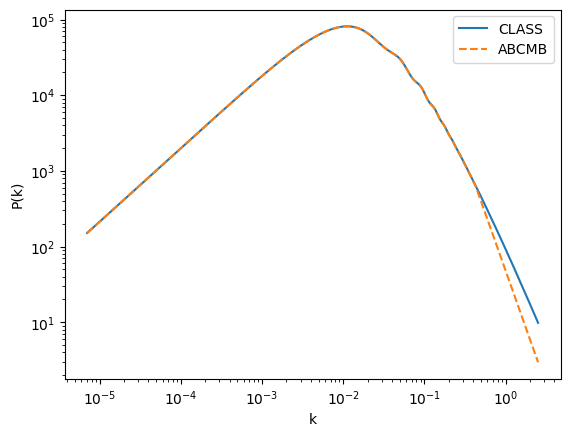

In [244]:
plt.loglog(class_k, class_Pk, label="CLASS")
plt.loglog(class_k, abcmb_Pk, "--", label="ABCMB")
plt.legend()
#plt.xlim((1.e-3, 1))
plt.xlabel("k")
plt.ylabel("P(k)")
plt.show()

In [7]:
from classy import Class

In [16]:
class_params = {
    "output": "mPk, lCl",
    "lensing": "yes",
    "z_max_pk": 1000,
    "H0": BG.params["h"]*100,
    "omega_b": BG.params["omega_b"],
    "omega_cdm": BG.params["omega_cdm"],
    "tau_reio": 0.0586,
    "N_ur": BG.params["N_ur"],
    "YHe": BG.params["YHe"],
    "lensing": "no",
    "N_ncdm": 0}    

In [17]:
class_lcdm = Class()
class_lcdm.set(class_params)
class_lcdm.compute()

In [18]:
zs = jnp.array([0., 10., 100., 1000.])
k = jnp.logspace(-4., -0.3, 500, base=10)

/state/partition1/job-66401383/ipykernel_1291522/4275723911.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


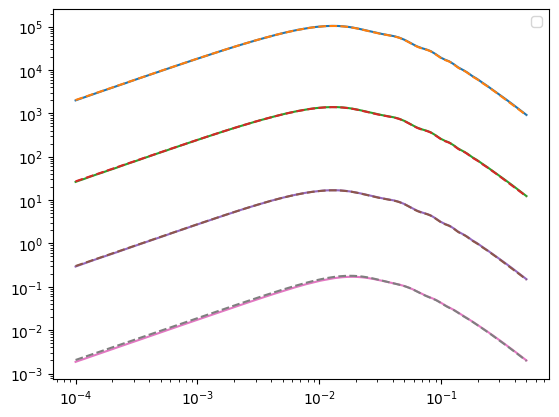

In [25]:
for z in zs:
    abcmb_res = SS.Pk_lin(k, z, PT, BG)
    class_res = np.vectorize(class_lcdm.pk_lin)(k, z)
    plt.loglog(k, SS.Pk_lin(k, z, PT, BG))
    plt.loglog(k, np.vectorize(class_lcdm.pk_lin)(k, z), "--")
    #plt.loglog(k, abs(abcmb_res - class_res)/class_res, label=z)
plt.legend()
plt.show()

# Lensing

## Lensing Cl

In [30]:
class_pp = class_lcdm.raw_cl(3000)["pp"]
class_tt = class_lcdm.raw_cl(3000)["tt"]
class_te = class_lcdm.raw_cl(3000)["te"]
class_ee = class_lcdm.raw_cl(3000)["ee"]
class_ell = class_lcdm.raw_cl(3000)["ell"]
abcmb_pp = vmap(SS.lensing_Cl, in_axes=(0, None, None))(class_ell, PT, BG)

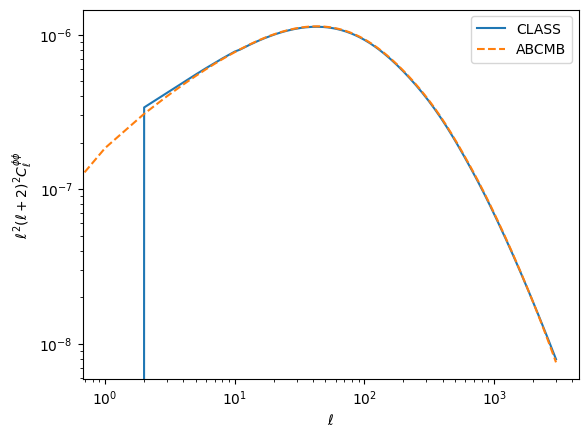

In [31]:
plt.plot(class_ell, (class_ell*(class_ell+1))**2 * class_pp, label="CLASS")
plt.plot(class_ell, (class_ell*(class_ell+1))**2 * abcmb_pp, "--", label="ABCMB")
plt.legend()
plt.xscale("log")
plt.yscale("log")
#plt.xlim((2, 2000))
plt.xlabel(r"$\ell$")
plt.ylabel(r"$\ell^2(\ell+2)^2C_\ell^{\phi\phi}$")
plt.show()

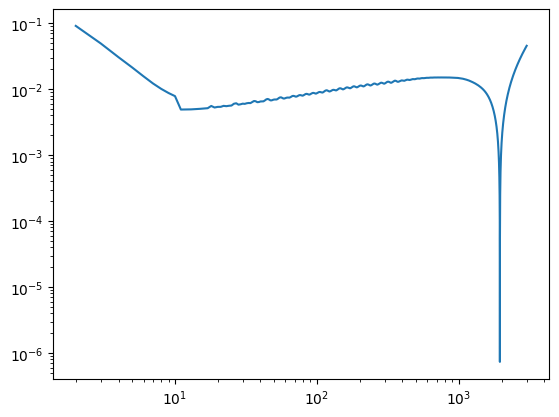

In [32]:
plt.plot(class_ell, abs(class_pp - abcmb_pp)/class_pp)
plt.xscale("log")
plt.yscale("log")
#plt.xlim((2, 2000))
plt.show()

## Temperature Cl

$$
C_\ell = \int_{0.98}^{1} \xi(\beta) J_0(\ell \beta) d\cos{\beta}
$$

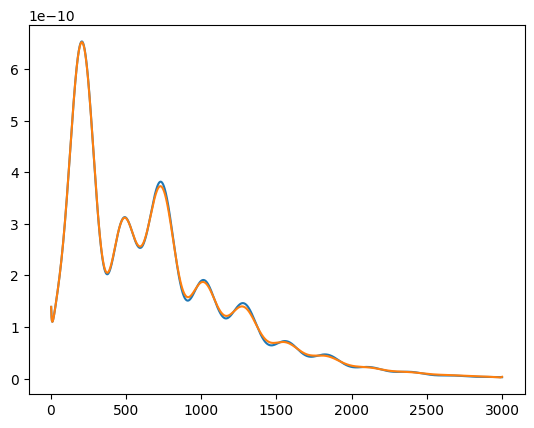

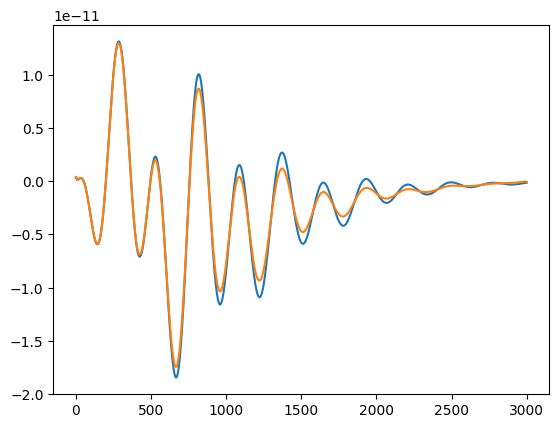

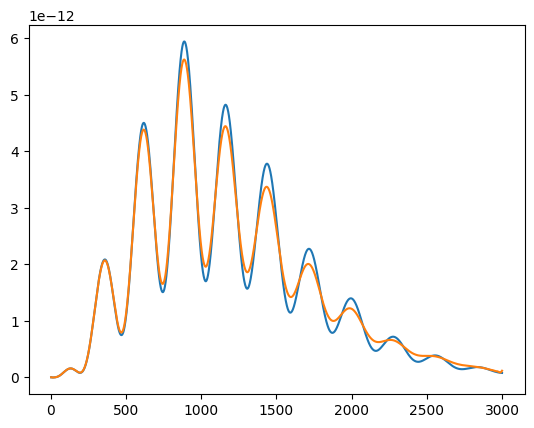

In [36]:
#res = SS.lense_ClTT(class_ell[2:], class_pp[2:], class_ell[2:]*(class_ell[2:]+1)*class_tt[2:]/2./jnp.pi)
#plt.loglog(class_ell[2:], class_ell[2:]*(class_ell[2:]+1)*res)
#ells = jnp.arange(2, 2000)
ells = class_ell[2:]
cltt = class_tt[2:]
clte = class_te[2:]
clee = class_ee[2:]
clpp = class_pp[2:]
pref = ells*(ells+1)/2./jnp.pi
#clpp = jnp.zeros(ells.size)
res_tt, res_te, res_ee = eqx.filter_jit(SS.lensed_Cls)(ells, cltt, clte, clee, PT, BG)
plt.plot(ells, pref*cltt)
plt.plot(ells, pref*(res_tt+cltt))
plt.show()

plt.plot(ells, pref*clte)
plt.plot(ells, pref*(res_te+clte))
plt.show()

plt.plot(ells, pref*clee)
plt.plot(ells, pref*(res_ee+clee))
plt.show()

In [47]:
f = eqx.filter_jit(SS.lensed_Cls)
for i in range(2):
    s = time.time()
    res_tt, res_te, res_ee = f(ells, cltt, clte, clee, PT, BG)
    res_tt.block_until_ready()
    print(time.time() - s)

16.553486347198486
11.142034769058228


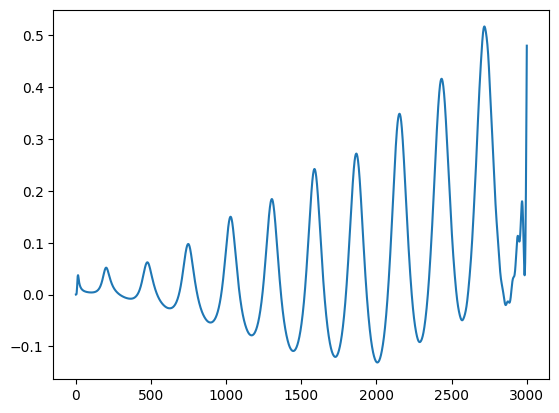

In [304]:
#plt.plot(ells, res_tt/cltt)
#plt.plot(ells, res_te/clte)
plt.plot(ells, res_ee/clee)
plt.show()

## Wigner Matrices

In [104]:
f = jit(tools.lensing_d00)
betas = jnp.linspace(0, jnp.pi/16., 1000)
l     = jnp.arange(2, 1003)
mu    = jnp.cos(betas)
print(f(mu, l).shape)

(1000, 1001)


In [55]:
betas = jnp.linspace(0, jnp.pi/16., 1000)
l     = jnp.arange(2, 1000)
mu    = jnp.cos(betas)

d00  = tools.lensing_d00(mu, l)
d11  = tools.lensing_d11(mu, l)
d1m1 = tools.lensing_d1m1(mu, l)
d2m2 = tools.lensing_d2m2(mu, l)

In the large $\ell$ limit, the Wigner matrices approach Bessel J functions as
$$
\lim_{\ell\rightarrow \infty}d_{mn}^{\ell}(\beta) \longrightarrow (-1)^{n-m} J_{m-n}(\ell \beta)\, .
$$
It serves to check the asymptotic behavior to make sure the recursion relations were correct.

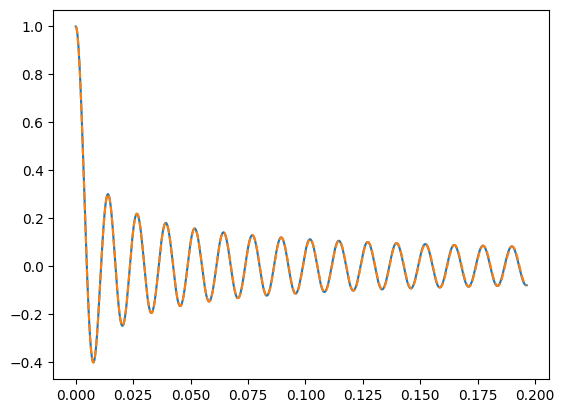

In [19]:
l = 500
plt.plot(betas, d00[:, l-2])
plt.plot(betas, scipy.special.jv(0, l*betas), "--")
plt.show()

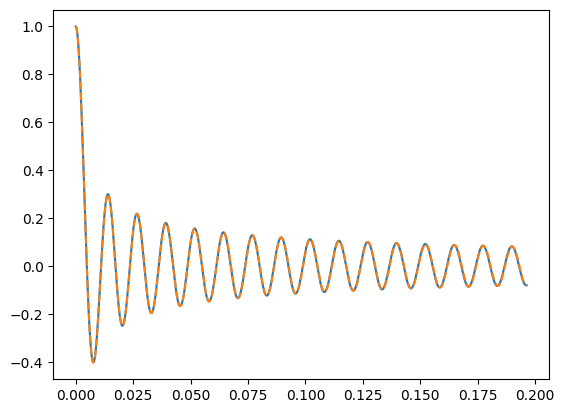

In [20]:
l = 500
plt.plot(betas, d11[:, l-2], label="d11")
plt.plot(betas, scipy.special.jv(0, l*betas), "--")
plt.show()

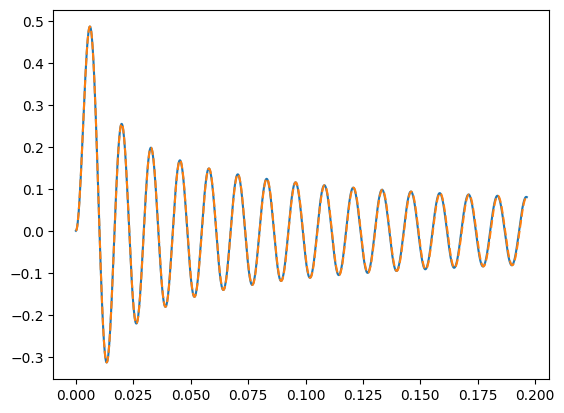

In [21]:
l = 500
plt.plot(betas, d1m1[:, l-2], label="d1m1")
plt.plot(betas, scipy.special.jv(2, l*betas), "--")
plt.show()

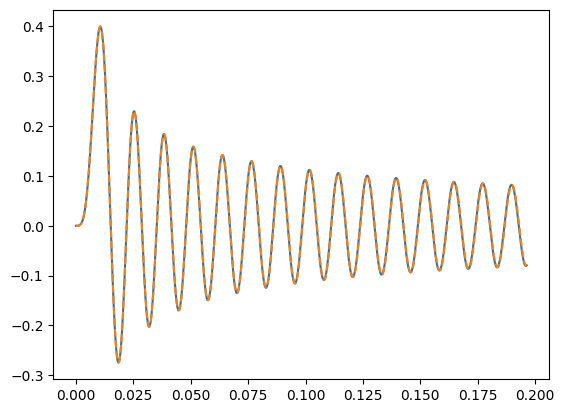

In [62]:
l = 500
plt.plot(betas, d2m2[:, l-2], label="d1m1")
plt.plot(betas, scipy.special.jv(4, l*betas), "--")
plt.show()

In [233]:
# Attempt at general solution
def wigner_d_matrix(mu, ells, m, n):
    """
    m, n are integers. m must be positive and greater than n.
    ells an array ([m, m+1, m+2, ..., ellmax])
    """
    
    # base case: ell = m
    def base_val(mu):
        beta = jnp.arccos(mu)
        norm = jnp.sqrt((2*m+1)/2) * jnp.sqrt(factorial(2*m)/(factorial(m+n)*factorial(m-n)))
        return norm * jnp.cos(beta/2.)**(m+n)*(-jnp.sin(beta/2.))**(m-n)
        #return norm * jnp.sqrt((1+mu)/2)**(m+n) * jnp.sqrt((1-mu)/2)**(m-n)

    normA = jnp.sqrt((2*ells+3)/(2*ells+1))
    normC = jnp.sqrt((2*ells+3)/(2*ells-1))
    denom = jnp.sqrt((ells+1)**2-m**2) * jnp.sqrt((ells+1)**2-n**2)
    A = jnp.nan_to_num(normA * (ells+1)*(2*ells+1) / denom, 0)
    B = jnp.nan_to_num(-A * m * n / ells / (ells+1), 0)
    C = jnp.nan_to_num(-normC * jnp.sqrt(ells**2-m**2) * jnp.sqrt(ells**2-n**2) / denom * (ells+1)/ells, 0)

    def one_mu(mu):
        d_start = base_val(mu) # Corresponds to ellmin = m
                
        def recursive_dlp1(carry, inputs):
            # For the first iteration, will take d1 and d2, compute d3.
            dl, dlm1 = carry 
            a, b, c = inputs

            # Compute dlp1
            dlp1 = a*mu*dl + b*dl + c*dlm1

            # Save dl, then make dl->dlm1, dlp1->dl
            return (dlp1, dl), dl

        # run scan for l = 2..lmax-1
        (_, _), res = lax.scan(recursive_dlp1, (d_start, 0.), (A, B, C))
        return res * jnp.sqrt(2./(2.*ells+1))

    return vmap(one_mu)(mu)

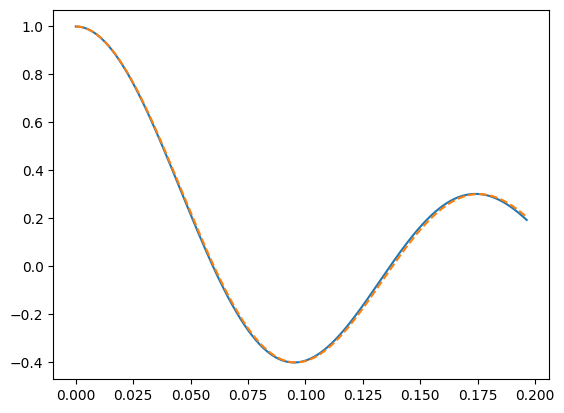

In [245]:
m = 4
n = 4
betas = jnp.linspace(0, jnp.pi/16., 1000)
l     = jnp.arange(m, 1000)
mu    = jnp.cos(betas)
d = jit(wigner_d_matrix)(mu, l, m, n)

l_plot = 10*m
plt.plot(betas, d[:, l_plot-m])
plt.plot(betas, (-1)**(n-m)*scipy.special.jv(m-n, l_plot*betas), "--")
plt.show()

In [248]:
d.shape
zeros = jnp.zeros((mu.size, m-2))
d_patched = jnp.concatenate((zeros, d), axis=1)

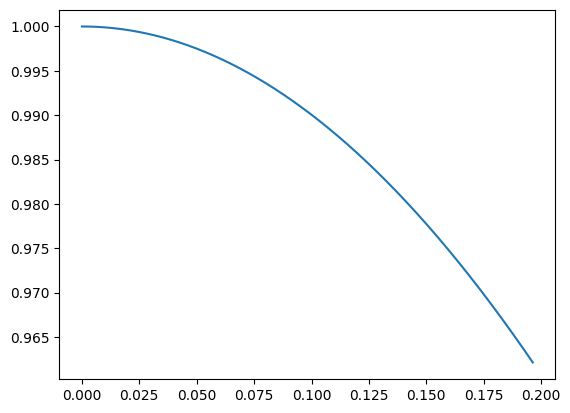

In [252]:
plt.plot(betas, d_patched[:, 2])

In [280]:
arr = jnp.ones(5)

5